In [1]:
!pip uninstall datasets -y
!pip install -U datasets
!pip install -U huggingface_hub
!pip install -U pyarrow
!pip install rapidfuzz
!pip install pandas pyarrow requests

Found existing installation: datasets 5.0.0
Uninstalling datasets-5.0.0:
  Successfully uninstalled datasets-5.0.0
  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
Using cached datasets-5.0.0-py3-none-any.whl (555 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import random
import re
import warnings
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.sparse import hstack
from rapidfuzz import fuzz
from transformers import Trainer
from transformers import TrainingArguments
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from rapidfuzz import fuzz
import string
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from tqdm import tqdm

warnings.filterwarnings("ignore")

C:\Users\vennila raj\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\vennila raj\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Environment Setup

In [2]:
# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device :", device)

Using Device : cpu


# data loading and exploration

In [5]:
# Dataset URL
url = "https://huggingface.co/datasets/glue/resolve/main/qqp/train-00000-of-00001.parquet"

# Load Dataset
df = pd.read_parquet(url)

# Shape of Dataset
print("Dataset Shape:", df.shape)

# First 5 Rows
df.head()

Dataset Shape: (363846, 4)


,question1,question2,label,idx
0,How is the life of a math student? Could you describe your own experiences?,Which level of prepration is enough for the exam jlpt5?,0,0
1,How do I control my horny emotions?,How do you control your horniness?,1,1
2,What causes stool color to change to yellow?,What can cause stool to come out as little balls?,0,2
3,What can one do after MBBS?,What do i do after my MBBS ?,1,3
4,Where can I find a power outlet for my laptop at Melbourne Airport?,"Would a second airport in Sydney, Australia be needed if a high-speed rail link was created between Melbourne and Sydney?",0,4


In [6]:
print("Dataset Information")
print("-"*50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 363846 entries, 0 to 363845
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   question1  363846 non-null  str  
 1   question2  363846 non-null  str  
 2   label      363846 non-null  int64
 3   idx        363846 non-null  int32
dtypes: int32(1), int64(1), str(2)
memory usage: 51.3 MB


In [7]:
print("Statistical Summary")
print("-"*50)

df.describe(include='all')

Statistical Summary
--------------------------------------------------


,question1,question2,label,idx
count,363846,363846,363846.000000,363846.000000
unique,266325,273393,NaN,NaN
top,How do I improve my English speaking?,What are the best ways to lose weight?,NaN,NaN
freq,46,110,NaN,NaN
mean,NaN,NaN,0.369327,181922.500000
std,NaN,NaN,0.482623,105033.437359
min,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,0.000000,90961.250000
50%,NaN,NaN,0.000000,181922.500000
75%,NaN,NaN,1.000000,272883.750000


In [8]:
print("Columns:")
print(df.columns.tolist())

Columns:
['question1', 'question2', 'label', 'idx']


In [9]:
df.sample(5)

,question1,question2,label,idx
215130,Why do some people think that having a baby is a blessing?,Why is having a baby a blessing?,1,215130
234600,How vulnerable are paratroopers on their descent? If they are fired at can they fire back?,Are conventional paratroopers obsolete?,0,234600
118406,Examples of sole proprietorship? The,How are sole proprietorships started?,0,118406
284746,Why don't I get answers for some of my questions on Quora?,Why do some questions get more answers here in Quora?,1,284746
300683,Do Kashmiris wants to join Pakistan?,Do the people of Kashmir want to join Pakistan or India? Why?,0,300683


In [10]:
print("Missing Values")
print("-"*50)

print(df.isnull().sum())

Missing Values
--------------------------------------------------
question1    0
question2    0
label        0
idx          0
dtype: int64


In [11]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_percent
})

print(missing_df)

           Missing Count  Missing Percentage
question1              0                 0.0
question2              0                 0.0
label                  0                 0.0
idx                    0                 0.0


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
print(df['label'].value_counts())

label
0    229468
1    134378
Name: count, dtype: int64


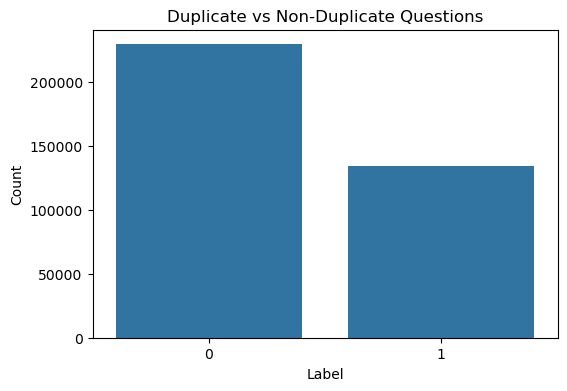

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Duplicate vs Non-Duplicate Questions")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [15]:
df['q1_length'] = df['question1'].astype(str).apply(len)

print(df['q1_length'].describe())

count    363846.000000
mean         59.629742
std          30.043435
min           1.000000
25%          39.000000
50%          52.000000
75%          72.000000
max         627.000000
Name: q1_length, dtype: float64


In [16]:
df['q2_length'] = df['question2'].astype(str).apply(len)

print(df['q2_length'].describe())

count    363846.000000
mean         60.192389
std          33.999355
min           1.000000
25%          39.000000
50%          51.000000
75%          72.000000
max        1175.000000
Name: q2_length, dtype: float64


In [17]:
# Word Count Analysis

df['q1_word_count'] = df['question1'].astype(str).apply(
    lambda x: len(x.split())
)
df['q2_word_count'] = df['question2'].astype(str).apply(
    lambda x: len(x.split())
)

In [18]:
print("Question1 Word Count")
print(df['q1_word_count'].describe())

print("\nQuestion2 Word Count")
print(df['q2_word_count'].describe())

Question1 Word Count
count    363846.000000
mean         10.942822
std           5.437638
min           1.000000
25%           7.000000
50%          10.000000
75%          13.000000
max         125.000000
Name: q1_word_count, dtype: float64

Question2 Word Count
count    363846.000000
mean         11.183468
std           6.325961
min           1.000000
25%           7.000000
50%          10.000000
75%          13.000000
max         237.000000
Name: q2_word_count, dtype: float64


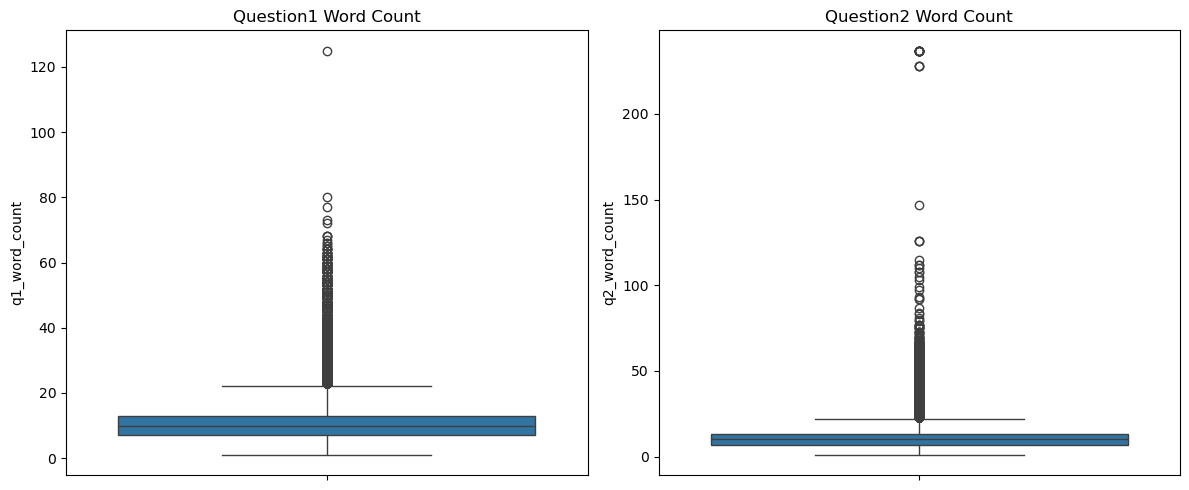

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df['q1_word_count'])
plt.title("Question1 Word Count")
plt.subplot(1,2,2)
sns.boxplot(y=df['q2_word_count'])
plt.title("Question2 Word Count")
plt.tight_layout()
plt.show()

In [20]:
# Class label analysis
label_percent = df['label'].value_counts(normalize=True)*100
print(label_percent)

label
0    63.067342
1    36.932658
Name: proportion, dtype: float64


# Data preprocessing

In [21]:
def preprocess_classical(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [22]:
text = df['question1'].iloc[0]

print("Original")
print(text)

lower = text.lower()
print("\nAfter Lowercase")
print(lower)

punct = re.sub(r'[^a-z0-9 ]',' ',lower)
print("\nAfter Punctuation Removal")
print(punct)

Original
How is the life of a math student? Could you describe your own experiences?

After Lowercase
how is the life of a math student? could you describe your own experiences?

After Punctuation Removal
how is the life of a math student  could you describe your own experiences 


# Feature Engineering 

In [23]:
# Pairwise Similarity
df['q1_clean'] = df['question1'].apply(preprocess_classical)
df['q2_clean'] = df['question2'].apply(preprocess_classical)

In [24]:
df['q1_len'] = df['q1_clean'].apply(len)
df['q2_len'] = df['q2_clean'].apply(len)

df['q1_words'] = df['q1_clean'].apply(lambda x: len(x.split()))
df['q2_words'] = df['q2_clean'].apply(lambda x: len(x.split()))

In [25]:
def common_words(row):

    w1 = set(row['q1_clean'].split())
    w2 = set(row['q2_clean'].split())

    return len(w1.intersection(w2))

df['common_words'] = df.apply(common_words, axis=1)

In [26]:
def jaccard_similarity(row):

    w1 = set(row['q1_clean'].split())
    w2 = set(row['q2_clean'].split())

    union = len(w1.union(w2))

    if union == 0:
        return 0

    return len(w1.intersection(w2))/union

df['jaccard'] = df.apply(jaccard_similarity, axis=1)

In [27]:
def overlap_ratio(q1,q2):

    w1 = set(str(q1).lower().split())
    w2 = set(str(q2).lower().split())

    denominator = min(len(w1),len(w2))

    if denominator == 0:
        return 0

    return len(w1.intersection(w2))/denominator

df['overlap_ratio'] = df.apply(
    lambda x: overlap_ratio(
        x['question1'],
        x['question2']
    ),
    axis=1
)

In [28]:
# Length Difference
df['len_diff'] = abs(df['q1_len'] - df['q2_len'])

# Word Count Difference
df['word_diff'] = abs(df['q1_words'] - df['q2_words'])

In [29]:
df['fuzz_ratio'] = df.apply(
    lambda x: fuzz.ratio(
        str(x['question1']),
        str(x['question2'])
    ),
    axis=1
)

df['partial_ratio'] = df.apply(
    lambda x: fuzz.partial_ratio(
        str(x['question1']),
        str(x['question2'])
    ),
    axis=1
)

df['token_sort_ratio'] = df.apply(
    lambda x: fuzz.token_sort_ratio(
        str(x['question1']),
        str(x['question2'])
    ),
    axis=1
)

df['token_set_ratio'] = df.apply(
    lambda x: fuzz.token_set_ratio(
        str(x['question1']),
        str(x['question2'])
    ),
    axis=1
)

In [30]:
feature_cols = [
    'q1_len','q2_len','len_diff',
    'q1_words','q2_words','word_diff',
    'common_words','jaccard','overlap_ratio',
    'fuzz_ratio',
    'partial_ratio',
    'token_sort_ratio',
    'token_set_ratio'
]

X_features = df[feature_cols]

y = df['label']

print(X_features.shape)

(363846, 13)


# Train - Test Split

In [31]:
X_train_feat,\
X_test_feat,\
y_train,\
y_test = train_test_split(

    X_features,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print(X_train_feat.shape)
print(X_test_feat.shape)

(291076, 13)
(72770, 13)


In [33]:
X_train_text,\
X_test_text,\
_,_ = train_test_split(
    df[['q1_clean','q2_clean']],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
train_questions = pd.concat([
    X_train_text['q1_clean'],
    X_train_text['q2_clean']
])

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)
tfidf.fit(train_questions)

TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2))

In [35]:
q1_train_tfidf = tfidf.transform(
    X_train_text['q1_clean']
)

q2_train_tfidf = tfidf.transform(
    X_train_text['q2_clean']
)

q1_test_tfidf = tfidf.transform(
    X_test_text['q1_clean']
)

q2_test_tfidf = tfidf.transform(
    X_test_text['q2_clean']
)

In [36]:
# Feature fusion
X_train_final = hstack([
    q1_train_tfidf,
    q2_train_tfidf,
    X_train_feat.values
])

X_test_final = hstack([
    q1_test_tfidf,
    q2_test_tfidf,
    X_test_feat.values
])

print(X_train_final.shape)
print(X_test_final.shape)

(291076, 10013)
(72770, 10013)


In [37]:
# =====================================================
# LOGISTIC REGRESSION
# =====================================================
lr = LogisticRegression(
    C=2.0,
    max_iter=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train_final, y_train)
lr_pred = lr.predict(X_test_final)

# =====================================================
# LINEAR SVM 
# =====================================================
svm = LinearSVC(
    C=2.0,
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

svm.fit(X_train_final, y_train)
svm_pred = svm.predict(X_test_final)

# =====================================================
# RANDOM FOREST 
# =====================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)
rf_pred = rf.predict(X_test_final)

# =====================================================
# XGBOOST 
# =====================================================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_final, y_train)
xgb_pred = xgb.predict(X_test_final)

In [38]:
# Transformer Pair Classification (Cross-Encoder)

train_df,test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [39]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

train_encodings = tokenizer(
    train_df['question1'].tolist(),
    train_df['question2'].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_df['question1'].tolist(),
    test_df['question2'].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /bert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001E4A75645F0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 6fdbe4ca-bf05-4411-a4de-30971ba5d4f0)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /bert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001E4A3FAFC80>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 422007ce-f276-49b5-99f6-5c7a85ab551f)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/toke

In [40]:
#Load Model
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001E4BC325A00>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: b2fbc32b-0e6a-44b5-948a-4e6578e4de90)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001E4B7D9F1D0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: fcfd5ac1-9feb-4e32-8b18-364d55b56769)')' thrown while requesting HEAD https://huggingface.co

In [41]:
q1_emb = sbert.encode(
    test_df['question1'].tolist(),
    batch_size=128,
    show_progress_bar=True
)

q2_emb = sbert.encode(
    test_df['question2'].tolist(),
    batch_size=128,
    show_progress_bar=True
)

Batches:   0%|          | 0/569 [00:00<?, ?it/s]

Batches:   0%|          | 0/569 [00:00<?, ?it/s]

In [42]:
similarity = np.sum(
    q1_emb * q2_emb,
    axis=1
) / (
    np.linalg.norm(q1_emb,axis=1)
    *
    np.linalg.norm(q2_emb,axis=1)
)

In [43]:
predictions = (
    similarity >= 0.80
).astype(int)

# Training and Tuning

In [44]:
y_true = test_df['label'].values

In [45]:
# =========================================================
# MODEL COMPARISON
# =========================================================

results = [

    {
        "Model":"Logistic Regression",
        "Accuracy":accuracy_score(y_test, lr_pred),
        "Precision":precision_score(y_test, lr_pred),
        "Recall":recall_score(y_test, lr_pred),
        "F1 Score":f1_score(y_test, lr_pred)
    },

    {
        "Model":"Linear SVM",
        "Accuracy":accuracy_score(y_test, svm_pred),
        "Precision":precision_score(y_test, svm_pred),
        "Recall":recall_score(y_test, svm_pred),
        "F1 Score":f1_score(y_test, svm_pred)
    },

    {
        "Model":"Random Forest",
        "Accuracy":accuracy_score(y_test, rf_pred),
        "Precision":precision_score(y_test, rf_pred),
        "Recall":recall_score(y_test, rf_pred),
        "F1 Score":f1_score(y_test, rf_pred)
    },

    {
        "Model":"XGBoost",
        "Accuracy":accuracy_score(y_test, xgb_pred),
        "Precision":precision_score(y_test, xgb_pred),
        "Recall":recall_score(y_test, xgb_pred),
        "F1 Score":f1_score(y_test, xgb_pred)
    },

    {
        "Model":"Sentence-BERT",
        "Accuracy":accuracy_score(y_true, predictions),
        "Precision":precision_score(y_true, predictions),
        "Recall":recall_score(y_true, predictions),
        "F1 Score":f1_score(y_true, predictions)
    }

]

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n========== MODEL COMPARISON ==========\n")
print(comparison_df)

# =========================================================
# BEST MODEL
# =========================================================

best_model = comparison_df.iloc[0]

print("\n========== BEST MODEL ==========\n")

print("Model      :", best_model['Model'])
print("Accuracy   :", round(best_model['Accuracy'],4))
print("Precision  :", round(best_model['Precision'],4))
print("Recall     :", round(best_model['Recall'],4))
print("F1 Score   :", round(best_model['F1 Score'],4))

# =========================================================
# SAVE RESULTS
# =========================================================

comparison_df.to_csv(
    "all_model_comparison.csv",
    index=False
)

print("\nResults saved as all_model_comparison.csv")


========== MODEL COMPARISON ==========

                 Model  Accuracy  Precision    Recall  F1 Score
1           Linear SVM  0.787564   0.676532  0.813998  0.738926
3              XGBoost  0.786986   0.701620  0.736419  0.718599
4        Sentence-BERT  0.781902   0.681907  0.767488  0.722171
0  Logistic Regression  0.752783   0.633032  0.786650  0.701530
2        Random Forest  0.750144   0.722376  0.525413  0.608349

========== BEST MODEL ==========

Model      : Linear SVM
Accuracy   : 0.7876
Precision  : 0.6765
Recall     : 0.814
F1 Score   : 0.7389

Results saved as all_model_comparison.csv


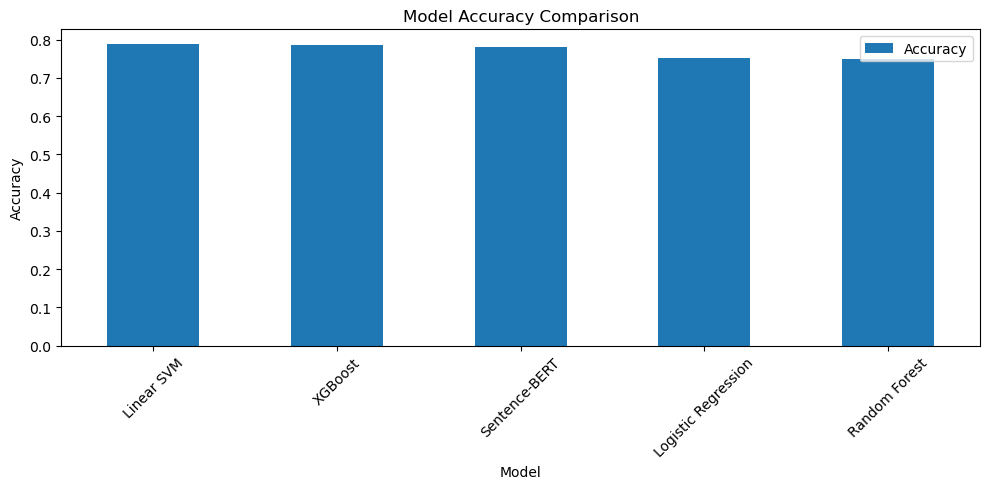

In [46]:
comparison_df.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    figsize=(10,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [47]:
# ==========================================================
# QQP DUPLICATE QUESTION DETECTION SYSTEM
# ==========================================================

def extract_features(q1, q2):

    q1 = str(q1).strip().lower()
    q2 = str(q2).strip().lower()

    # -----------------------------
    # Length Features
    # -----------------------------

    q1_len = len(q1)
    q2_len = len(q2)

    len_diff = abs(q1_len - q2_len)

    # -----------------------------
    # Word Count Features
    # -----------------------------

    q1_words = len(q1.split())
    q2_words = len(q2.split())

    word_diff = abs(q1_words - q2_words)

    # -----------------------------
    # Set Based Features
    # -----------------------------

    w1 = set(q1.split())
    w2 = set(q2.split())

    common_words = len(w1.intersection(w2))

    union_words = len(w1.union(w2))

    if union_words == 0:
        jaccard = 0
    else:
        jaccard = common_words / union_words

    min_words = min(len(w1), len(w2))

    if min_words == 0:
        overlap_ratio = 0
    else:
        overlap_ratio = common_words / min_words

    # -----------------------------
    # Fuzzy Features
    # -----------------------------

    fuzz_ratio = fuzz.ratio(q1, q2)

    partial_ratio = fuzz.partial_ratio(q1, q2)

    token_sort_ratio = fuzz.token_sort_ratio(q1, q2)

    token_set_ratio = fuzz.token_set_ratio(q1, q2)

    return [

        q1_len,
        q2_len,
        len_diff,

        q1_words,
        q2_words,
        word_diff,

        common_words,
        jaccard,
        overlap_ratio,

        fuzz_ratio,
        partial_ratio,
        token_sort_ratio,
        token_set_ratio
    ]

# ==========================================================
# DUPLICATE CHECK FUNCTION
# ==========================================================

def check_duplicate(q1, q2):

    # TF-IDF
    q1_tfidf = tfidf.transform([q1])

    q2_tfidf = tfidf.transform([q2])

    # Manual Features
    features = extract_features(q1, q2)

    feature_df = pd.DataFrame([features])

    # Combine
    X_runtime = hstack([
        q1_tfidf,
        q2_tfidf,
        feature_df.values
    ])

    # Debug Information
    print("\nRuntime Feature Shape :", X_runtime.shape)
    print("Model Expected Shape  :", svm.n_features_in_)

    # Prediction
    pred = svm.predict(X_runtime)[0]

    return pred

# ==========================================================
# INTERACTIVE SYSTEM
# ==========================================================

print("=" * 70)
print("QQP DUPLICATE QUESTION DETECTION SYSTEM")
print("=" * 70)

while True:

    print("\n")

    q1 = input("Enter Question 1 : ")

    q2 = input("Enter Question 2 : ")

    prediction = check_duplicate(q1, q2)

    print("\nRESULT")
    print("-" * 70)

    if prediction == 1:

        print("DUPLICATE QUESTION")
        print("Both questions have similar meaning.")

    else:

        print("NOT DUPLICATE")
        print("Questions have different meanings.")

    print("-" * 70)

    choice = input(
        "\nDo you want to test another pair? (y/n): "
    ).lower()

    if choice != "y":
        break

print("\nSystem Closed Successfully.")

QQP DUPLICATE QUESTION DETECTION SYSTEM




Enter Question 1 :  How can I learn Python?
Enter Question 2 :  What is the best way to learn Python?



Runtime Feature Shape : (1, 10013)
Model Expected Shape  : 10013

RESULT
----------------------------------------------------------------------
DUPLICATE QUESTION
Both questions have similar meaning.
----------------------------------------------------------------------



Do you want to test another pair? (y/n):  y


Enter Question 1 :  How can I learn Python?
Enter Question 2 :  Who won the FIFA World Cup?



Runtime Feature Shape : (1, 10013)
Model Expected Shape  : 10013

RESULT
----------------------------------------------------------------------
NOT DUPLICATE
Questions have different meanings.
----------------------------------------------------------------------



Do you want to test another pair? (y/n):  n



System Closed Successfully.
